<a href="https://colab.research.google.com/github/Chromanon/Multiple_Myeloma/blob/main/MM_pathway.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Topological Data Analysis (TDA) Pipeline for Multiple Myeloma Phenotyping

This notebook implements a Topological Data Analysis (TDA) pipeline to identify and analyze distinct metabolic and oncogenic phenotypes within a Multiple Myeloma (MM) patient cohort. By leveraging genomic data (SNVs) and clinical outcomes, we aim to uncover novel disease subtypes, particularly focusing on the "Low Burden" or "Dark Matter" cohort—patients exhibiting clinical symptoms (CRAB criteria) without canonical metabolic or cytogenetic drivers.

In [52]:
# Mounting google drive to download R-dependencies from sorce
message("Initializing GoogleDrive connection...")
system("python3 -c 'from google.colab import drive; drive.mount(\"/content/drive\")'")

wait_time <- 0
timeout <- 30
while(!dir.exists("/content/drive/MyDrive") && wait_time < timeout) {
  Sys.sleep(2)
  wait_time <- wait_time + 2
}

Initializing GoogleDrive connection...



In [53]:
system("apt-get update")
system("apt-get install -y libmpfr-dev libgmp3-dev") # Build TDA-dependencoes from source

my_lib <- "/content/drive/MyDrive/R_library"
if (!dir.exists(my_lib)) dir.create(my_lib, recursive = TRUE)
.libPaths(c(my_lib, .libPaths()))

if (!requireNamespace("vctrs", quietly = TRUE) || packageVersion("vctrs") < "0.7.1") {
  install.packages("vctrs", lib = my_lib, repos = "https://cloud.r-project.org")
}

In [54]:
libs <- c(

           "dplyr",
           "BiocManager",
           "tidyverse",
           "igraph"
           )

missing_libs <- libs[!(libs %in% installed.packages()[, "Package"])]
if(length(missing_libs)) install.packages(missing_libs, lib = my_lib, update = FALSE, ask = FALSE)

In [55]:
installed.packages(lib.loc = my_lib)[, "Package"]

BiocGenerics      BiocManager      BiocVersion         circlize 
  "BiocGenerics"    "BiocManager"    "BiocVersion"       "circlize" 
            clue       colorspace   ComplexHeatmap          DNAcopy 
          "clue"     "colorspace" "ComplexHeatmap"        "DNAcopy" 
      doParallel          foreach       GetoptLong            ggtda 
    "doParallel"        "foreach"     "GetoptLong"          "ggtda" 
   GlobalOptions           igraph          IRanges        iterators 
 "GlobalOptions"         "igraph"        "IRanges"      "iterators" 
        maftools      matrixStats         pheatmap              png 
      "maftools"    "matrixStats"       "pheatmap"            "png" 
         remotes          Rhtslib            rjson        S4Vectors 
       "remotes"        "Rhtslib"          "rjson"      "S4Vectors" 
           shape        TDAmapper 
         "shape"      "TDAmapper"

In [56]:
# install Biocunductor infrastucture, especially maftools
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")
bio_libs <- c(
              "maftools",
              "ComplexHeatmap"
              )

path_exists <- dir.exists(file.path(my_lib, bio_libs))
missing_bio <- bio_libs[!bio_libs %in% installed.packages(lib.loc = my_lib)[, "Package"]]

if(length(missing_bio) > 0){
  if (!require('BiocManager', quietly = TRUE)) install.packages("BiocManager")
  BiocManager::install(missing_bio, lib = my_lib, update = FALSE, ask = FALSE)
} else {
  print("Everything ok with packages")
}
invisible(lapply(bio_libs, library, character.only = TRUE))

[1] "Everything ok with packages"


In [57]:
library(dplyr)
library(ggplot2)
library(igraph)
library(tidyverse)

In [58]:
# if (!requireNamespace("TDA", quietly = TRUE, lib.loc = my_lib)) {
#   install.packages("TDA", lib = my_lib, repos = "https://cloud.r-project.org", type = "source")}
if (!requireNamespace("remotes", quietly = TRUE, lib.loc = my_lib)) {
  install.packages("remotes", lib = my_lib)}

library(remotes, lib.loc = my_lib)
if (!requireNamespace("ggtda", quietly = TRUE, lib.loc = my_lib)) {
  remotes::install_github("tdaverse/ggtda", lib = my_lib, upgrade = "never")}
if (!requireNamespace("TDAmapper", quietly = TRUE, lib.loc = my_lib)) {
  remotes::install_github("paultpearson/TDAmapper", lib = my_lib, upgrade = "never")}

In [59]:
library(TDAmapper, lib.loc = my_lib)
library(ggtda, lib.loc = my_lib)
library(magrittr)
library(maftools)

In [60]:
options(repr.plot.width = 14, repr.plot.height = 14)

In [61]:
ls(("package:maftools"))

[1] "annovarToMaf"            "bamreadcounts"          
 [3] "cancerhotspots"          "cancerhotspotsAggr"     
 [5] "clinicalEnrichment"      "coBarplot"              
 [7] "coGisticChromPlot"       "compareSignatures"      
 [9] "coOncoplot"              "drugInteractions"       
[11] "estimateSignatures"      "extractSignatures"      
[13] "filterMaf"               "forestPlot"             
[15] "genesToBarcodes"         "genotypeMatrix"         
[17] "getClinicalData"         "getCytobandSummary"     
[19] "getFields"               "getGeneSummary"         
[21] "getSampleSummary"        "gisticBubblePlot"       
[23] "gisticChromPlot"         "gisticCompare"          
[25] "gisticOncoPlot"          "gtMarkers"              
[27] "icgcSimpleMutationToMAF" "inferHeterogeneity"     
[29] "intersectMAF"            "lollipopPlot"           
[31] "lollipopPlot2"           "MAF"                    
[33] "maf2mae"                 "mafbarplot"             
[35] "mafCompare"              "mafSummary"             
[37] "mafSurvGroup"            "mafSurvival"            
[39] "math.score"              "merge_mafs"             
[41] "mutCountMatrix"          "oncodrive"              
[43] "oncoplot"                "oncostrip"              
[45] "pathways"                "pfamDomains"            
[47] "plotApobecDiff"          "plotCBSsegments"        
[49] "plotClusters"            "plotCophenetic"         
[51] "plotEnrichmentResults"   "plotmafSummary"         
[53] "plotMosdepth"            "plotMosdepth_t"         
[55] "plotOncodrive"           "plotPathways"           
[57] "plotProtein"             "plotSignatures"         
[59] "plotTiTv"                "plotVaf"                
[61] "prepareMutSig"           "prepAscat"              
[63] "prepAscat_t"             "rainfallPlot"           
[65] "read.maf"                "readGistic"             
[67] "sampleSwaps"             "segmentLogR"            
[69] "segSummarize"            "setdiffMAF"             
[71] "signatureEnrichment"     "somaticInteractions"    
[73] "subsetMaf"               "survGroup"              
[75] "tcgaAvailable"           "tcgaCompare"            
[77] "tcgaLoad"                "titv"                   
[79] "tmb"                     "trinucleotideMatrix"    
[81] "vafCompare"              "write.GisticSummary"    
[83] "write.mafSummary"

In [62]:
#checking file on server
url_dataset <- "https://datahub.assets.cbioportal.org/mm_broad.tar.gz"
file_name <- "mm_broad.tar.gz"

cmd_file <- sprintf("[ -f %s ]", file_name)
cmd_header <- sprintf("curl -I -f -L -s -o /dev/null -w '%%{http_code}' %s", url_dataset)

if ( system(cmd_file) == 0) {
  print("Archive_exists. Start working")
  } else {
  print("Need to load archive")
  header <- sprintf("curl -I ")
  if (system(cmd_header) != 0) {
      print("file_dont_exists_on_server. Search for mirrors")}
  else {
    cmd_load <- sprintf("curl -L -o %s %s", file_name, url_dataset)
    system(cmd_load)}}

[1] "Archive_exists. Start working"


In [63]:
#checking seemles and entegrity of file
etag <- "curl -I -L -s %s | grep -i etag | awk '{print $2}' | tr -d '\"\\r'"
expected_md5 <- system(sprintf(etag, url_dataset), intern = TRUE)
# print(expected_md5)
local_md5 <- system(sprintf("md5sum %s | awk '{print $1}'", file_name), intern = TRUE)
# print(local_md5)

In [64]:
if (expected_md5 != local_md5) {
  print('Something went wrong with archive with MAF! Terninated')
  quit(save = "no", status = 1, runLast = FALSE)
  }

In [65]:
base_dir <- getwd()
data_folder <- system(sprintf("tar -tf %s | head -n 1 | cut -f1 -d'/'", file_name), intern = TRUE)

In [66]:
full_path <- file.path(base_dir, data_folder)
full_path

[1] "/content/mm_broad"

In [67]:
if (!dir.exists(full_path)) {
  status <- system(sprintf("tar -xzf %s -C %s", file_name, base_dir))
  if (status != 0) quit(status = 1, save = "no" )
}

In [68]:
files_info <- file.info(list.files(full_path, full.names = TRUE))
print(files_info[, c("size", "mtime", "isdir")])

                                                size               mtime isdir
/content/mm_broad/case_lists                    4096 2024-08-12 19:14:26  TRUE
/content/mm_broad/data_clinical_patient.txt    15659 2024-08-12 20:36:21 FALSE
/content/mm_broad/data_clinical_sample.txt     21394 2024-08-12 20:36:21 FALSE
/content/mm_broad/data_mutations.txt        12149809 2024-08-12 20:36:21 FALSE
/content/mm_broad/LICENSE                        455 2024-08-12 19:14:26 FALSE
/content/mm_broad/meta_clinical_patient.txt      137 2024-08-12 19:14:26 FALSE
/content/mm_broad/meta_clinical_sample.txt       135 2024-08-12 19:14:26 FALSE
/content/mm_broad/meta_mutations.txt             332 2024-08-12 19:14:26 FALSE
/content/mm_broad/meta_study.txt                 289 2024-08-12 19:14:26 FALSE
/content/mm_broad/TDA_Clusters.csv             10488 2026-08-09 16:22:42 FALSE


In [69]:
maf_file_name <- system(sprintf("ls %s | grep -E 'data_mutations.*\\.txt|\\.maf$'", full_path), intern = TRUE)
maf_file_name

[1] "data_mutations.txt"

In [70]:
path_to_maf <- file.path(getwd(), data_folder, maf_file_name)
my_maf <-maftools::read.maf(maf=path_to_maf)

-Reading
-Validating
-Silent variants: 3199 
-Summarizing
--Possible FLAGS among top ten genes:
  TTN
  MUC16
-Processing clinical data
--Missing clinical data
-Finished in 2.416s elapsed (2.315s cpu) 


In [71]:
# showing total patients in Maf file
nrow(maftools::getSampleSummary(my_maf))

[1] 205

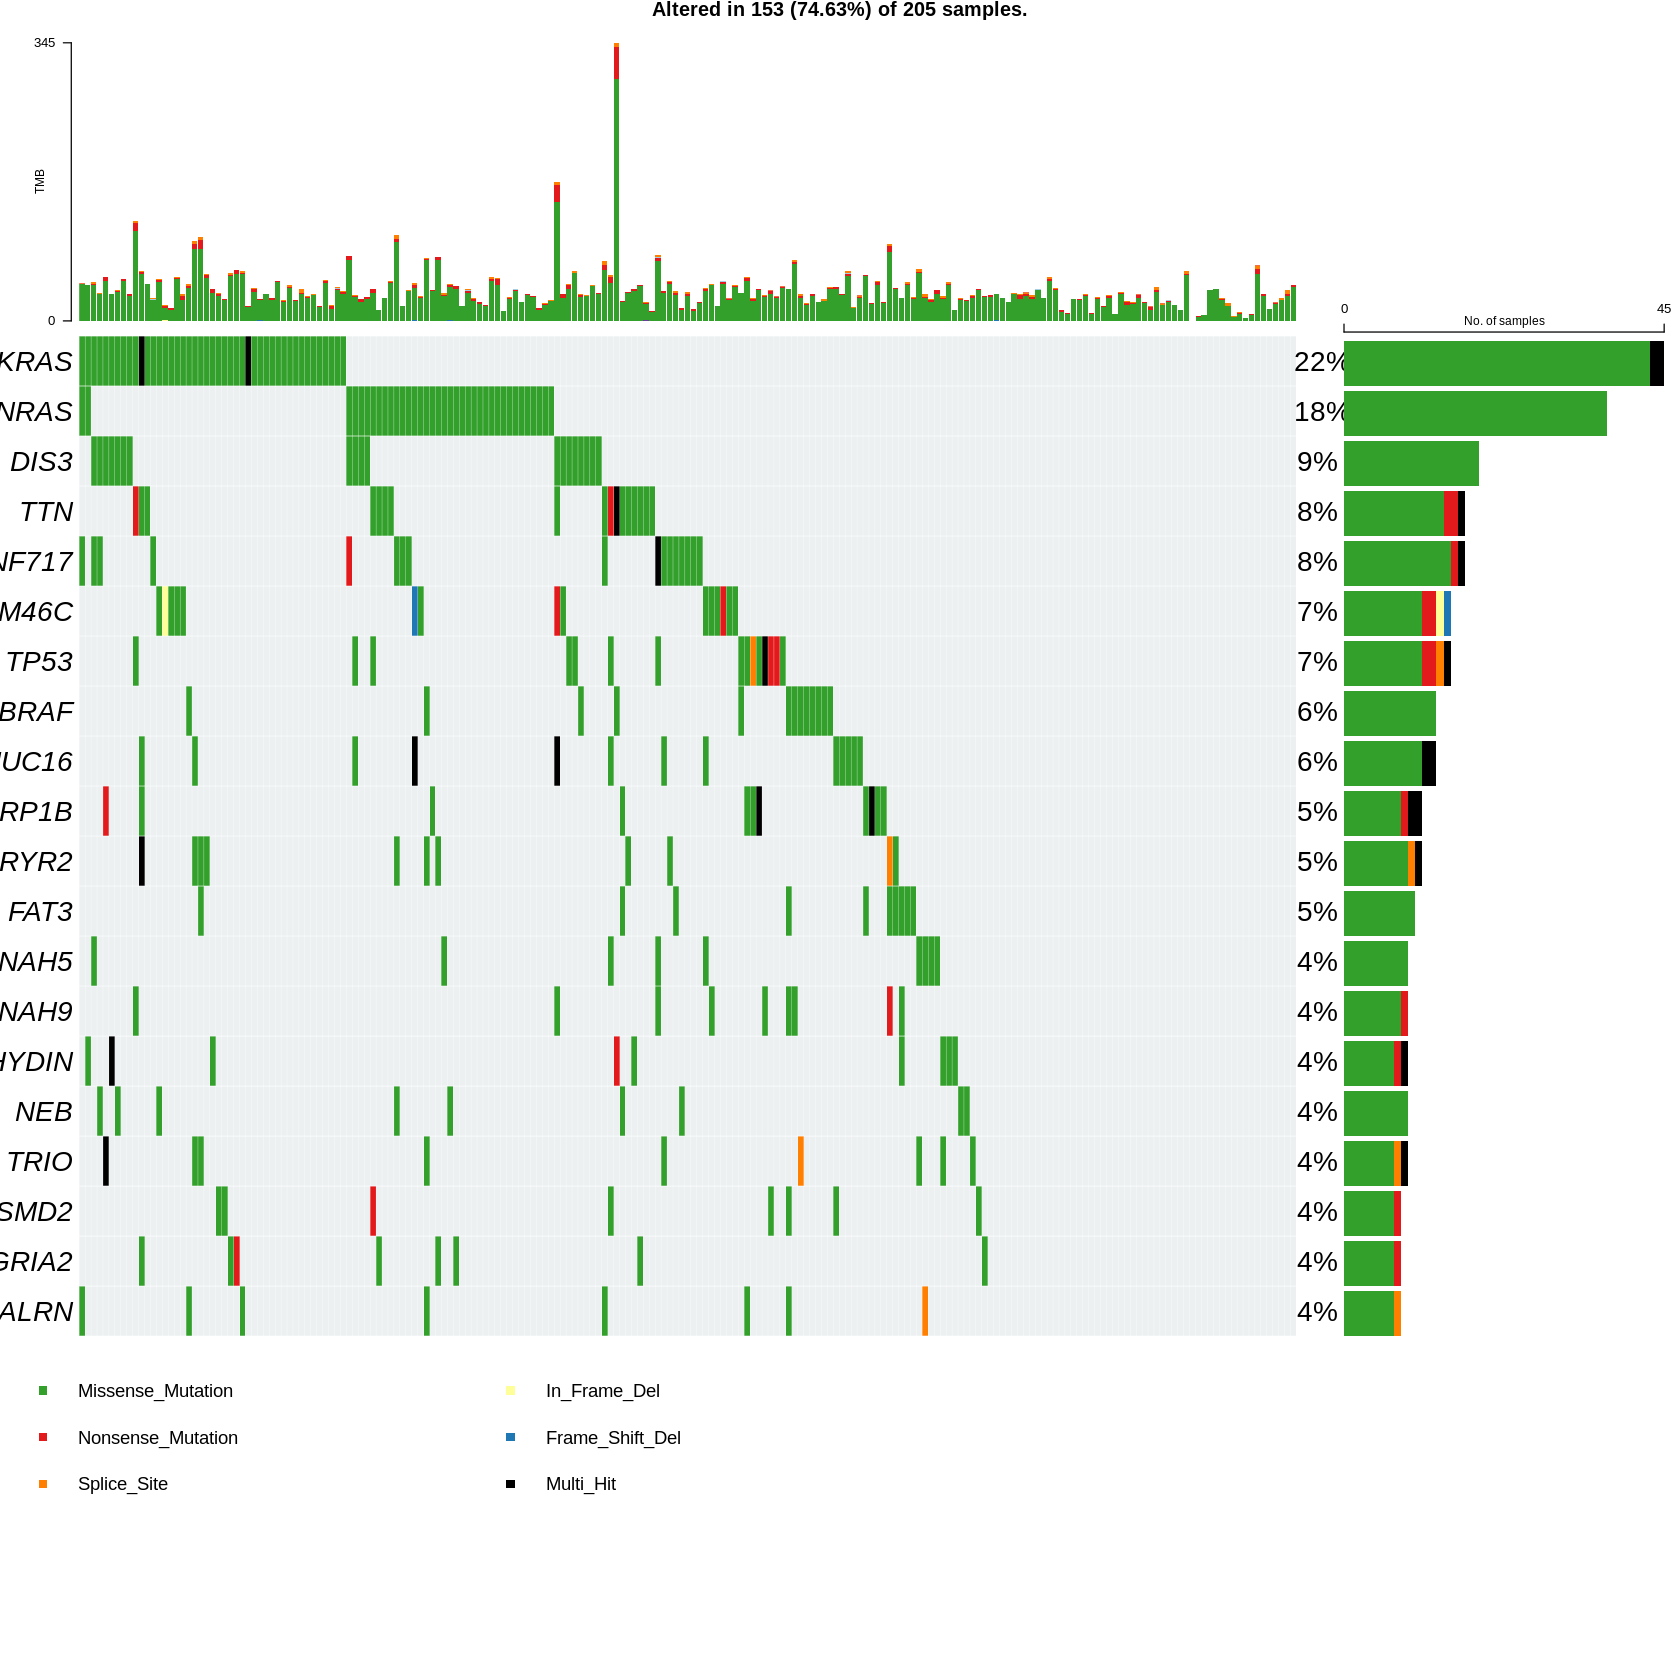

In [72]:
vane_plot <- maftools::oncoplot(maf = my_maf,
                                   top = 20,
                                   fontSize = 1.4,
                                   legendFontSize = 1.4,
                                   SampleNamefont = 1.4)

In [73]:
sample_sum <- maftools::getSampleSummary(my_maf)

In [74]:
# Pathways by Sanchez-Vega et al. (2018)
pathway_list <- list(
  `Cell_Cycle` = c("CDKN1A", "CDKN1B", "CDKN2A", "CDKN2B", "CDK4", "CDK6", "CCND1", "CCNE1", "RB1"),
  `Hippo` = c("STK4", "STK3", "LATS1", "LATS2", "YAP1", "TAZ", "TEAD1", "TEAD2", "TEAD3", "TEAD4"),
  `MYC` = c("MYC", "MYCL", "MYCN", "MAX", "MGA", "MLX", "MLXIP", "MLXIPL"),
  `NOTCH` = c("NOTCH1", "NOTCH2", "NOTCH3", "NOTCH4", "HES1", "HEY1", "DLL1", "DLL3", "DLL4", "JAG1", "JAG2"),
  `PI3K` = c("PIK3CA", "PIK3CB", "PIK3R1", "PIK3R2", "PTEN", "AKT1", "AKT2", "AKT3", "MTOR"),
  `RTK-RAS` = c("KRAS", "NRAS", "HRAS", "BRAF", "RAF1", "MAP2K1", "MAP2K2", "MAPK1", "MAPK3", "EGFR", "ERBB2", "MET"),
  `TP53` = c("TP53", "MDM2", "MDM4", "ATM", "ATR", "CHEK1", "CHEK2"),
  `WNT` = c("APC", "CTNNB1", "AXIN1", "AXIN2", "DVL1", "DVL2", "DVL3", "FZD1", "FZD2", "GSK3B"),
  `TGF-Beta` = c("TGFBR1", "TGFBR2", "SMAD2", "SMAD3", "SMAD4"),
  `NRF2` = c("NFE2L2", "KEAP1", "CUL3"),
  `NF-kB` = c("TRAF3", "CYLD", "BIRC2", "BIRC3", "NFKB1", "NFKB2", "IKBKB", "MAP3K14"),
  `Epigenetics_and_RNA` = c("WHSC1", "NSD2", "DIS3", "FAM46C", "TENT5C", "KMT2B", "KMT2C", "KDM6A", "TET2", "DNMT3A"))


In [75]:
pathway_df <- stack(pathway_list)
colnames(pathway_df) <- c("Gene", "Pathway")

barcodes <- maftools::genesToBarcodes(maf = my_maf, genes = pathway_df$Gene)

CDKN1A not found in MAF. Excluding it..
CDKN2A not found in MAF. Excluding it..
CDKN2B not found in MAF. Excluding it..
CCNE1 not found in MAF. Excluding it..
YAP1 not found in MAF. Excluding it..
TAZ not found in MAF. Excluding it..
TEAD2 not found in MAF. Excluding it..
TEAD4 not found in MAF. Excluding it..
MYCL not found in MAF. Excluding it..
MYCN not found in MAF. Excluding it..
MLX not found in MAF. Excluding it..
MLXIP not found in MAF. Excluding it..
NOTCH2 not found in MAF. Excluding it..
NOTCH4 not found in MAF. Excluding it..
HES1 not found in MAF. Excluding it..
HEY1 not found in MAF. Excluding it..
DLL1 not found in MAF. Excluding it..
DLL3 not found in MAF. Excluding it..
DLL4 not found in MAF. Excluding it..
JAG1 not found in MAF. Excluding it..
PIK3CA not found in MAF. Excluding it..
PIK3R1 not found in MAF. Excluding it..
PIK3R2 not found in MAF. Excluding it..
PTEN not found in MAF. Excluding it..
AKT2 not found in MAF. Excluding it..
AKT3 not found in MAF. Excluding

In [76]:
real_maf_genes <- my_maf@gene.summary$Hugo_Symbol

In [77]:
genes_to_test <- as.character(pathway_df$Gene)
print(genes_to_test)
# grep("KRAS", gene_to_test)
found_genes <- intersect(genes_to_test, real_maf_genes)

  [1] "CDKN1A"  "CDKN1B"  "CDKN2A"  "CDKN2B"  "CDK4"    "CDK6"    "CCND1"  
  [8] "CCNE1"   "RB1"     "STK4"    "STK3"    "LATS1"   "LATS2"   "YAP1"   
 [15] "TAZ"     "TEAD1"   "TEAD2"   "TEAD3"   "TEAD4"   "MYC"     "MYCL"   
 [22] "MYCN"    "MAX"     "MGA"     "MLX"     "MLXIP"   "MLXIPL"  "NOTCH1" 
 [29] "NOTCH2"  "NOTCH3"  "NOTCH4"  "HES1"    "HEY1"    "DLL1"    "DLL3"   
 [36] "DLL4"    "JAG1"    "JAG2"    "PIK3CA"  "PIK3CB"  "PIK3R1"  "PIK3R2" 
 [43] "PTEN"    "AKT1"    "AKT2"    "AKT3"    "MTOR"    "KRAS"    "NRAS"   
 [50] "HRAS"    "BRAF"    "RAF1"    "MAP2K1"  "MAP2K2"  "MAPK1"   "MAPK3"  
 [57] "EGFR"    "ERBB2"   "MET"     "TP53"    "MDM2"    "MDM4"    "ATM"    
 [64] "ATR"     "CHEK1"   "CHEK2"   "APC"     "CTNNB1"  "AXIN1"   "AXIN2"  
 [71] "DVL1"    "DVL2"    "DVL3"    "FZD1"    "FZD2"    "GSK3B"   "TGFBR1" 
 [78] "TGFBR2"  "SMAD2"   "SMAD3"   "SMAD4"   "NFE2L2"  "KEAP1"   "CUL3"   
 [85] "TRAF3"   "CYLD"    "BIRC2"   "BIRC3"   "NFKB1"   "NFKB2"   "IKBKB"  
 [92] "MAP3K

In [78]:
counts_matrix <- maftools::mutCountMatrix(maf = my_maf, includeSyn = FALSE)
genes_to_keep <- intersect(rownames(counts_matrix), found_genes)
cleab_matrix <- counts_matrix[genes_to_keep, ,drop=FALSE]

In [79]:
counts_matrix <- maftools::mutCountMatrix(maf = my_maf, includeSyn = FALSE)

genes_to_keep <- intersect(rownames(counts_matrix), found_genes)
clean_matrix <- counts_matrix[genes_to_keep, , drop = FALSE]

tda_matrix <- t(clean_matrix)
tda_matrix[tda_matrix > 0] <- 1

head(tda_matrix, 10)

,KRAS,NRAS,DIS3,TP53,FAM46C,BRAF,TRAF3,CCND1,ATM,EGFR,⋯,MTOR,NFKB2,NOTCH3,PIK3CB,STK3,STK4,TEAD1,TEAD3,TET2,TGFBR2
MM-0284,1,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
MM-0364,1,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,1,0,0,0
MM-0515,1,0,1,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
MM-0337,1,0,1,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
MM-0450,1,0,1,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
MM-0307,1,0,1,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
MM-0635,1,0,1,0,0,0,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,0
MM-0308,1,0,1,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
MM-0544,1,0,1,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
MM-0618,1,0,0,1,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [80]:
final_pathway_matrix <- matrix(0, nrow = nrow(tda_matrix), ncol = length(pathway_list))
colnames(final_pathway_matrix) <- names(pathway_list)
rownames(final_pathway_matrix) <- rownames(tda_matrix)

for (path_name in names(pathway_list)) {

  genes_in_system <- pathway_list[[path_name]]

  present_genes <- intersect(genes_in_system, colnames(tda_matrix))

  if (length(present_genes) > 0) {
    subset_mat <- tda_matrix[, present_genes, drop = FALSE]
    final_pathway_matrix[, path_name] <- as.numeric(rowSums(subset_mat) > 0)
  }
}

head(final_pathway_matrix, 5)

,Cell_Cycle,Hippo,MYC,NOTCH,PI3K,RTK-RAS,TP53,WNT,TGF-Beta,NRF2,NF-kB,Epigenetics_and_RNA
MM-0284,0,0,0,0,0,1,0,0,0,0,0,0
MM-0364,0,1,0,0,0,1,0,0,0,0,0,0
MM-0515,0,0,0,0,0,1,0,0,0,0,0,1
MM-0337,0,0,0,0,0,1,0,0,0,0,0,1
MM-0450,0,0,0,0,0,1,0,0,0,0,0,1


In [81]:
dist_matrix <- dist(final_pathway_matrix)

pca_res <- prcomp(final_pathway_matrix)
filter_values <- list(pca_res$x[,1], pca_res$x[,2])

mapper_output <- TDAmapper::mapper2D(
  distance_matrix = dist_matrix,
  filter_values = filter_values,
  num_intervals = c(6, 6),
  percent_overlap = 50,
  num_bins_when_clustering = 10
)


g <- graph.adjacency(mapper_output$adjacency, mode = "undirected")
node_burden <- sapply(mapper_output$points_in_vertex, function(pts) {
  mean(rowSums(final_pathway_matrix[pts, , drop=FALSE]))
})

color_pal <- colorRampPalette(c("skyblue", "yellow", "red"))(100)
node_colors <- color_pal[as.numeric(cut(node_burden, breaks = 100))]

[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"
[1] "Level set is empty"


null device 
          1

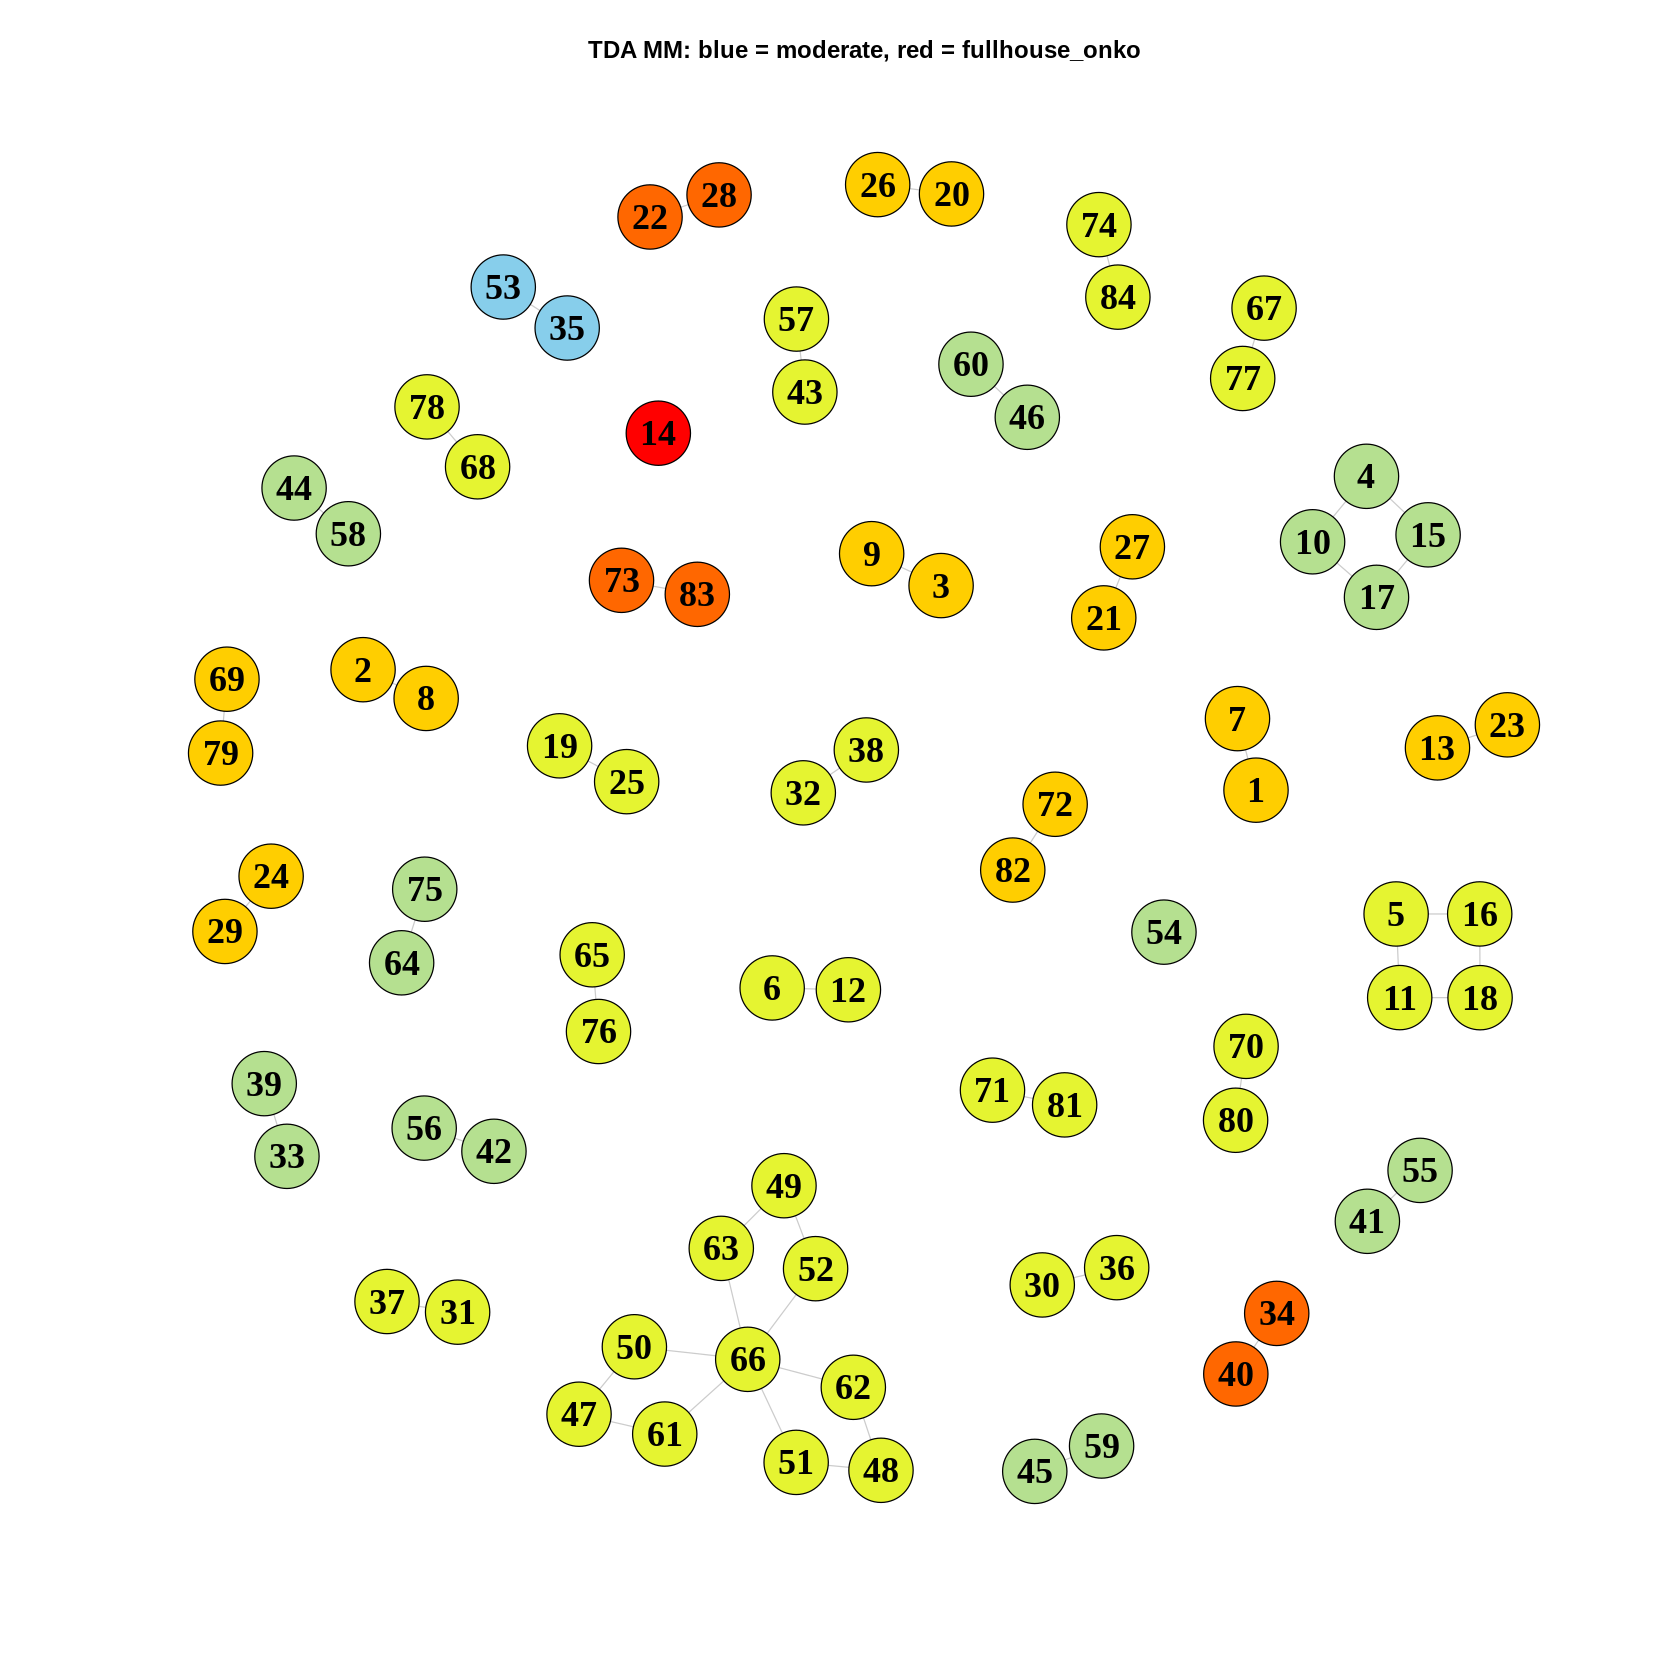

In [82]:
plot(g,
     layout = layout_with_fr(g),
     vertex.label = 1:vcount(g),
     vertex.label.color = "black",
     vertex.label.cex = 1.8,
     vertex.label.font = 2,
    vertex.color = node_colors,
     vertex.size = 10,
     vertex.label = NA,
     edge.color = "grey80",
     main = "TDA MM: blue = moderate, red = fullhouse_onko")

dev.off()

In [83]:
if (exists("patient_in_node")) rm(patient_in_node)
target_node_id <- 70
idx <- mapper_output$points_in_vertex[[target_node_id]]
current_patient_ids <- rownames(final_pathway_matrix)[idx]
message(sprintf("NOdes №%d: found %d patients", target_node_id, length(current_patient_ids)))
print(current_patient_ids)
if (length(idx) > 0) {
  node_stats <- colMeans(final_pathway_matrix[idx, , drop=FALSE])
    print("Active pathways")
  print(round(node_stats[node_stats > 0.1], 2))
} else {
  message("Empty nodes")
}

NOdes №70: found 5 patients



[1] "MM-0329" "MM-0609" "MM-0581" "MM-0383" "MM-442" 
[1] "Active pathways"
Cell_Cycle    RTK-RAS 
         1          1 


In [84]:
mapper_output$points_in_vertex[[7]]

MM-0638 MM-0533 
     81     111

In [85]:
patient_groups <- rep("Unknown", nrow(final_pathway_matrix))
names(patient_groups) <- rownames(final_pathway_matrix)


for (node_id in 1:length(mapper_output$points_in_vertex)) {

  # folks in node
  idx <- mapper_output$points_in_vertex[[node_id]]
  if (length(idx) == 0) next

  # get top 70 broken metabolic pathways
  node_stats <- colMeans(final_pathway_matrix[idx, , drop=FALSE])
  dominant_pathways <- names(node_stats)[node_stats > 0.7]

  # create low burden cluster
  label <- "Low_Burden"
  if (length(dominant_pathways) > 0) {
    label <- paste(dominant_pathways, collapse = "+")
  }

  p_ids <- rownames(final_pathway_matrix)[idx]
  patient_groups[p_ids] <- label
}


results_df <- data.frame(
  Patient_ID = names(patient_groups),
  Cluster_Type = patient_groups
)

results_df %>% count(Cluster_Type, sort = TRUE) %>%
  rename(Count = n) %>%
  head(20)

,Cluster_Type,Count
,<chr>,<int>
1,Low_Burden,72
2,RTK-RAS,48
3,RTK-RAS+Epigenetics_and_RNA,17
4,Epigenetics_and_RNA,10
5,TP53,6
6,Cell_Cycle+RTK-RAS,5
7,RTK-RAS+NF-kB,4
8,Cell_Cycle,3
9,RTK-RAS+TP53,3


In [86]:
# loading clinical data
sample_file <- file.path(full_path, "data_clinical_sample.txt")
sample_data <- read.delim(sample_file, comment.char = "#", stringsAsFactors = FALSE)

sample_data$Tumor_Sample_Barcode <- sample_data$PATIENT_ID

current_clin <- maftools::getClinicalData(my_maf)

if (!"FISH_TRANSLOCATION" %in% colnames(current_clin)){
  cols_to_merge <- setdiff(colnames(sample_data), "PATIENT_ID")
  merged_clin <- merge(current_clin, sample_data, by = "Tumor_Sample_Barcode", all.x = TRUE)
  my_maf@clinical.data <- merged_clin
}

if (exists("patient_groups")) {
    comparison_df <- data.frame(
      Patient_ID = names(patient_groups),
      TDA_Cluster = patient_groups,
      stringsAsFactors = FALSE
  )

  indices <- match(comparison_df$Patient_ID, sample_data$PATIENT_ID)
  comparison_df$FISH <- sample_data$FISH_TRANSLOCATION[indices]
  comparison_df$Hyperdiploid <- sample_data$HYPERDIPLOID[indices]


  print("FISH dsitribution in Low_Burden group (Blue node):")
  low_burden_fish <- table(comparison_df$FISH[comparison_df$TDA_Cluster == "Low_Burden"])
  print(low_burden_fish)


  print("FISH distribution in group TP53:") # "TP53" - red node
  tp53_fish <- table(comparison_df$FISH[comparison_df$TDA_Cluster == "TP53"])
  print(tp53_fish)

  print("Fish in RTK-RAS+Epigenetics_and_RNA")
  rtk_ras_e_fish <- table(comparison_df$FISH[comparison_df$TDA_Cluster == "RTK-RAS+Epigenetics_and_RNA"])
  print(rtk_ras_e_fish)

  print("Fish in RTK-RAS") # RTK-RAS
  rtk_ras_fish <- table(comparison_df$FISH[comparison_df$TDA_Cluster == "RTK-RAS"])
  print(rtk_ras_fish)

} else {
  message("something went wrong")
}

[1] "FISH dsitribution in Low_Burden group (Blue node):"

t(11;14)  t(4;14) 
       8        2 
[1] "FISH distribution in group TP53:"

t(11;14) 
       1 
[1] "Fish in RTK-RAS+Epigenetics_and_RNA"

t(11;14) t(14;16)  t(4;14) 
       3        1        3 
[1] "Fish in RTK-RAS"

(-17p13) t(11;14)  t(4;14) 
       1        8        1 


In [87]:
head(comparison_df, 5)

,Patient_ID,TDA_Cluster,FISH,Hyperdiploid
,<chr>,<chr>,<chr>,<chr>
MM-0284,MM-0284,RTK-RAS,t(11;14),No
MM-0364,MM-0364,Hippo+RTK-RAS,NA,No
MM-0515,MM-0515,RTK-RAS+Epigenetics_and_RNA,NA,Yes
MM-0337,MM-0337,RTK-RAS+Epigenetics_and_RNA,NA,Yes
MM-0450,MM-0450,RTK-RAS+Epigenetics_and_RNA,NA,No


In [88]:
# Hyperdiploid distribution
print("Hyperdiploidia in group Low_Burden")
print(table(comparison_df$Hyperdiploid[comparison_df$TDA_Cluster == "Low_Burden"]))

print("Hyperdiploidia in group RTK-RAS:")
print(table(comparison_df$Hyperdiploid[comparison_df$TDA_Cluster == "RTK-RAS"]))

print("Hyperdiploidia in group TP53:")
print(table(comparison_df$Hyperdiploid[comparison_df$TDA_Cluster == "TP53"]))

print("Hyperdiploidia in grou Epigenetics_and_RNA:")
print(table(comparison_df$Hyperdiploid[comparison_df$TDA_Cluster == "Epigenetics_and_RNA"]))

[1] "Hyperdiploidia in group Low_Burden"

 No Yes 
 30  39 
[1] "Hyperdiploidia in group RTK-RAS:"

 No Yes 
 13  33 
[1] "Hyperdiploidia in group TP53:"

 No Yes 
  1   4 
[1] "Hyperdiploidia in grou Epigenetics_and_RNA:"

 No Yes 
  4   6 


In [89]:
data_clinical_patient_path <- file.path(full_path, "data_clinical_patient.txt")
patient_data <- read.delim(data_clinical_patient_path, comment.char = "#", stringsAsFactors = FALSE)

In [90]:
patient_data %>%
  count(PATIENT_DEATH_REASON)

PATIENT_DEATH_REASON,n
<chr>,<int>
Other,6
Progression of disease,35
NA,170


reason of death are uninformative, stop doing in this derection

In [91]:
# Emphasasing by anoter way, seatching for of cause of desiese it cytogenetic
sample_data %>%
  # count(ONCOTREE_CODE),
  count(FISH_TRANSLOCATION)

FISH_TRANSLOCATION,n
<chr>,<int>
(-17p13),1
t(11;14),34
t(14;16),2
t(4;14),13
NA,161


In [92]:
final_df <- comparison_df %>%
  left_join(patient_data %>% select(PATIENT_ID, PATIENT_DEATH_REASON),
            by = c("Patient_ID" = "PATIENT_ID")) %>%

  mutate(
    Status = case_when(
      is.na(PATIENT_DEATH_REASON) ~ "Alive",
      PATIENT_DEATH_REASON %in% c("Progression of disease", "Other") ~ "Dead"
    )
  )

In [93]:
low_burden_summary <- final_df %>%
  filter(TDA_Cluster == "Low_Burden") %>%
  count(FISH,  Hyperdiploid, name = "Count") %>%
  arrange(desc(Count))
print(as.data.frame(low_burden_summary))

      FISH Hyperdiploid Count
1     <NA>          Yes    35
2     <NA>           No    24
3 t(11;14)           No     4
4 t(11;14)          Yes     4
5     <NA>         <NA>     3
6  t(4;14)           No     2


In [94]:
# explain MM from low_burden hyperploid - 35, fish - 6, both - 4, total - 45 patients
# without fish or hyperploid - 24, empty data -27
missing_stat <- final_df %>%
  filter(TDA_Cluster == "Low_Burden") %>%
  filter(
    (is.na(FISH) | FISH == "No") &
    (is.na(Hyperdiploid) | Hyperdiploid == "No")
  ) %>%
    count(FISH, Hyperdiploid, name = "Count")
  print(missing_stat)

  FISH Hyperdiploid Count
1 <NA>           No    24
2 <NA>         <NA>     3


In [95]:
# Found 27 patient without broken methabolic pathways and no cytogenetic signs
# But this patient has CRAB criterias and clinical signs.
# Found 27 good, potencial candidates to investigate by single-cell, micro ENV of
# marrow bone and flow cytometry

head(final_df, 5)

,Patient_ID,TDA_Cluster,FISH,Hyperdiploid,PATIENT_DEATH_REASON,Status
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,MM-0284,RTK-RAS,t(11;14),No,NA,Alive
2,MM-0364,Hippo+RTK-RAS,NA,No,Other,Dead
3,MM-0515,RTK-RAS+Epigenetics_and_RNA,NA,Yes,NA,Alive
4,MM-0337,RTK-RAS+Epigenetics_and_RNA,NA,Yes,NA,Alive
5,MM-0450,RTK-RAS+Epigenetics_and_RNA,NA,No,NA,Alive


--Possible FLAGS among top ten genes:
  TTN
  MUC16
  USH2A
-Processing clinical data


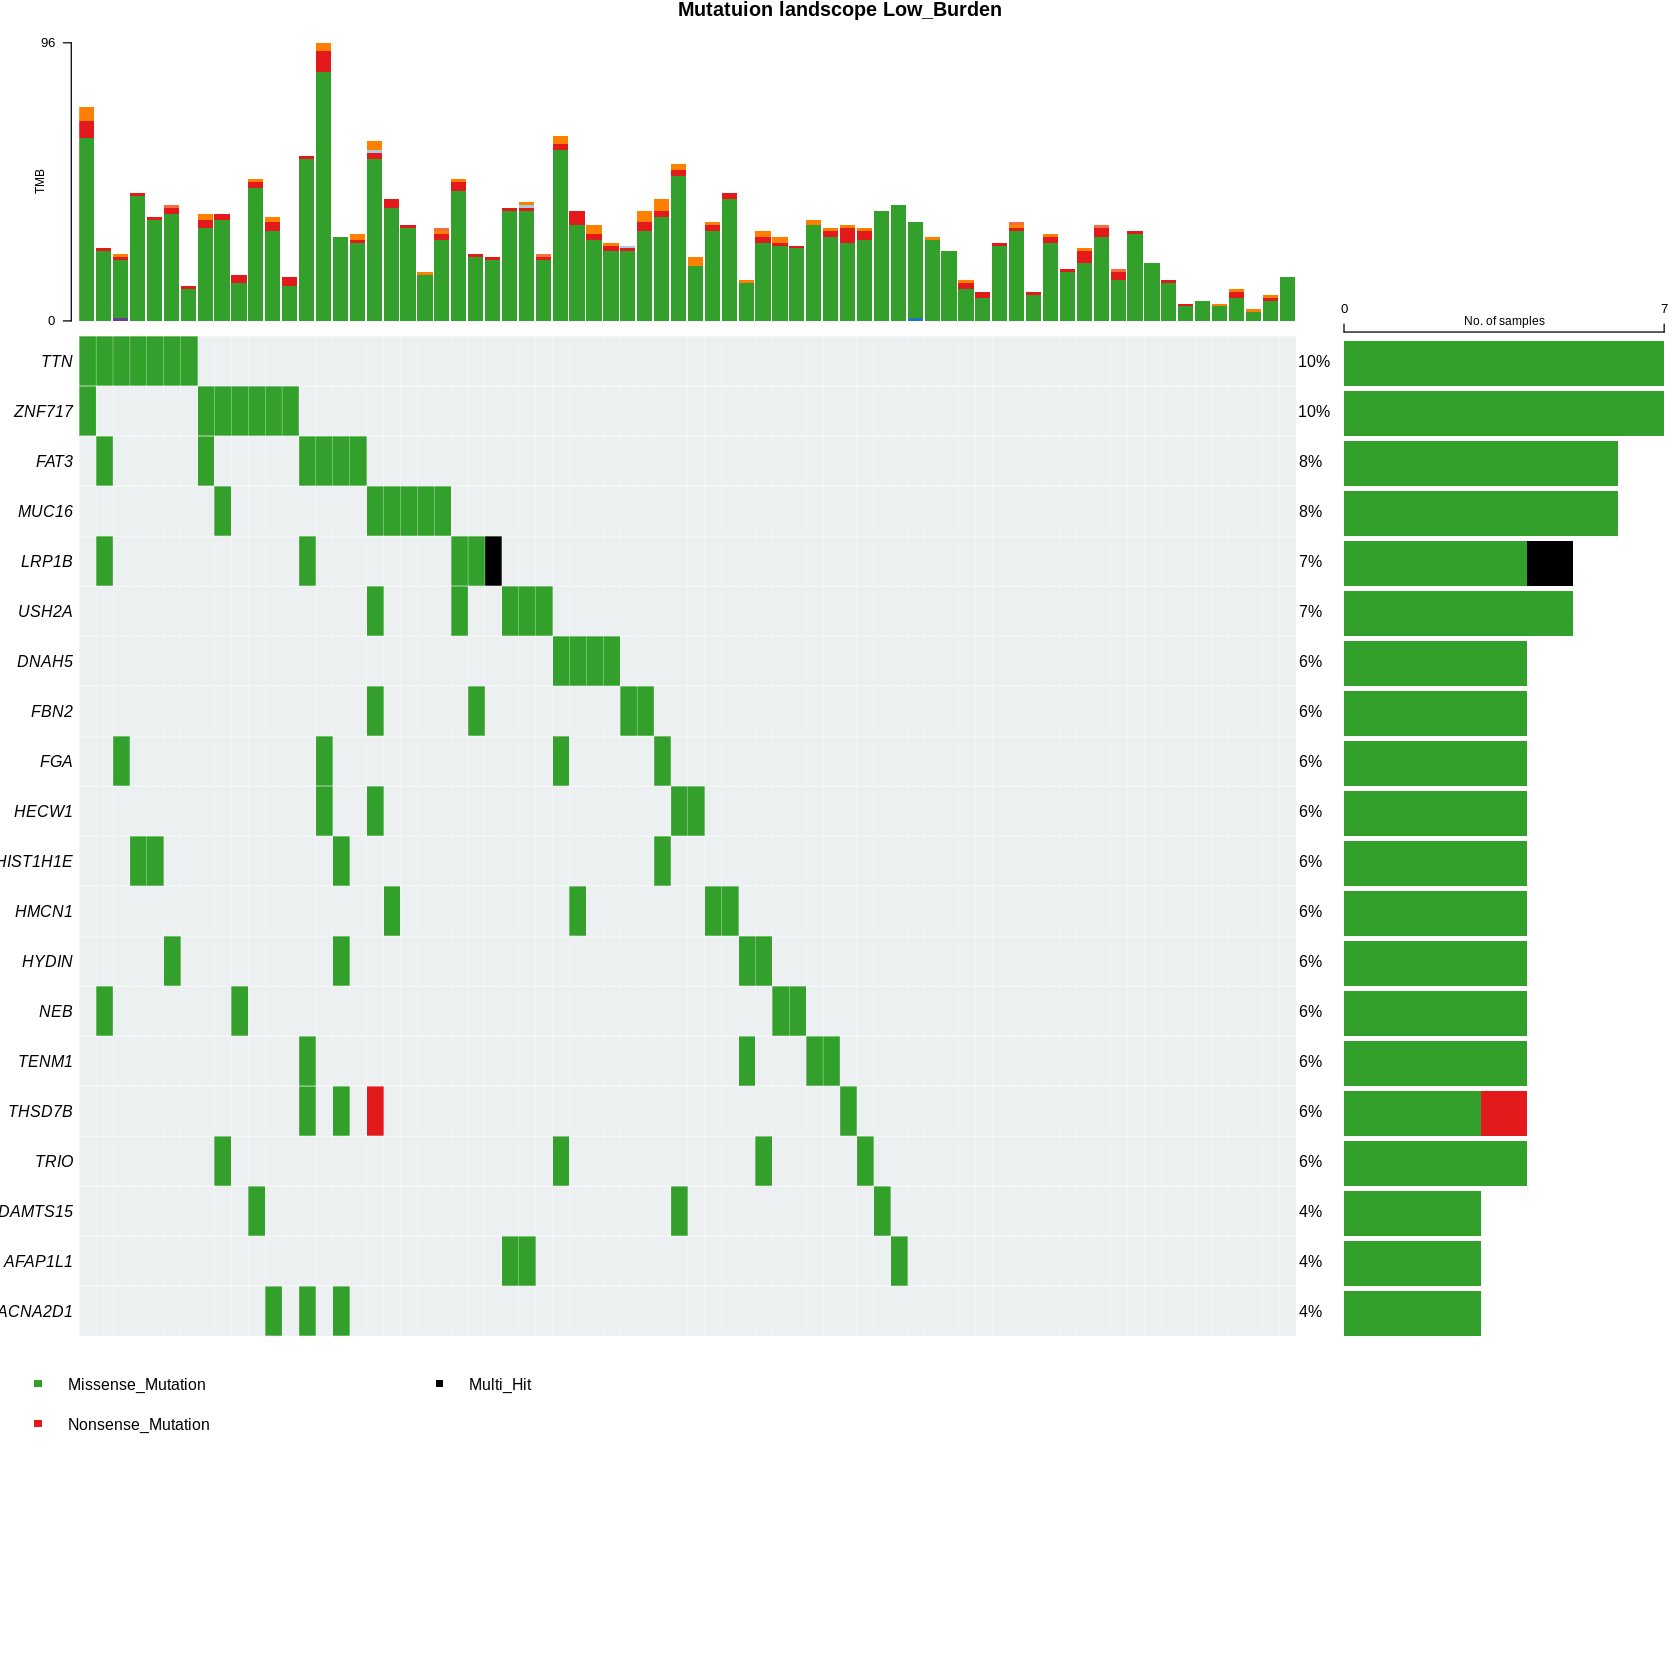

In [96]:
# Last atempt find some importance genes in MAF file,
# I can lose something
low_burden_ids <- names(patient_groups[patient_groups == "Low_Burden"])
low_burden_maf <- subsetMaf(maf = my_maf, tsb = low_burden_ids)

oncoplot(maf = low_burden_maf, top = 20,
         titleText = "Mutatuion landscope Low_Burden")

In [97]:
# had hint from maftools about gene-passenger like TTN, MUC16, USH2A
gene_summary <- maftools::getGeneSummary(low_burden_maf)

# just genes passenger list
flags_to_ignore <- c("TTN", "MUC16", "USH2A", "RYR2", "SYNE1", "OBSCN", "FLG", "DNAH5", "CSMD1", "LRP1B")

clean_top_genes <- gene_summary %>%
  filter(!Hugo_Symbol %in% flags_to_ignore) %>%
  mutate(Percent_Mutated = round((MutatedSamples / 72) * 100, 1)) %>%
  select(Hugo_Symbol, MutatedSamples, Percent_Mutated) %>%
  head(25)

print(as.data.frame(clean_top_genes))

   Hugo_Symbol MutatedSamples Percent_Mutated
1       ZNF717              7             9.7
2         FAT3              6             8.3
3         FBN2              4             5.6
4          FGA              4             5.6
5        HECW1              4             5.6
6     HIST1H1E              4             5.6
7        HMCN1              4             5.6
8        HYDIN              4             5.6
9          NEB              4             5.6
10       TENM1              4             5.6
11      THSD7B              4             5.6
12        TRIO              4             5.6
13    ADAMTS15              3             4.2
14     AFAP1L1              3             4.2
15    CACNA2D1              3             4.2
16       CMYA5              3             4.2
17     CNTNAP5              3             4.2
18       EPHA7              3             4.2
19      FAM47A              3             4.2
20        FAT1              3             4.2
21      INTS12              3     

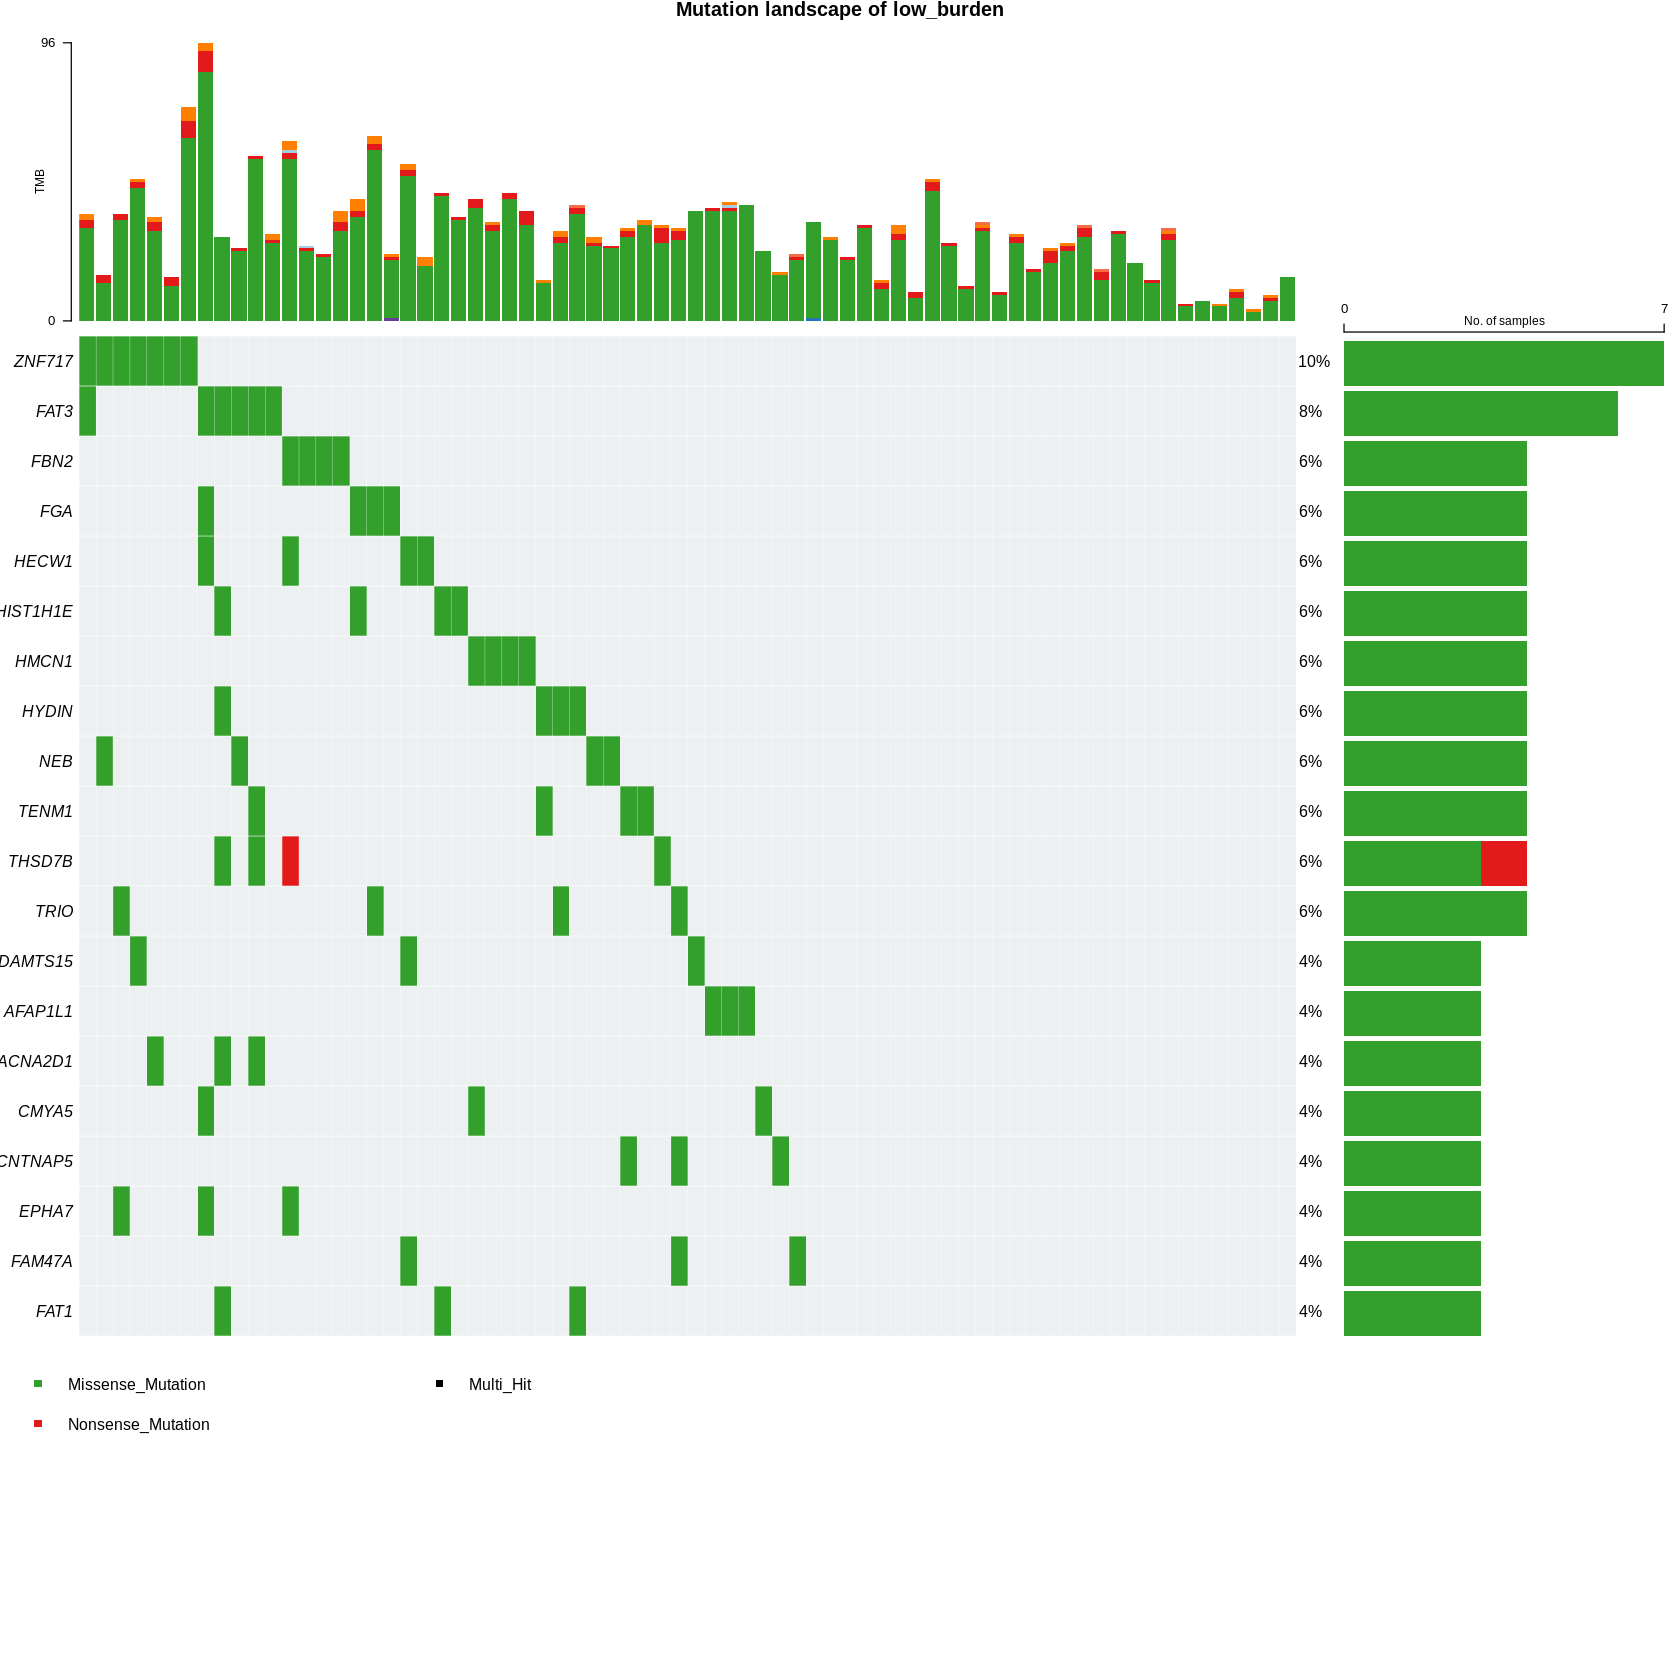

In [98]:
# the same information that in previous table will be on plot
clean_top_genes <- maftools::getGeneSummary(low_burden_maf) %>%
  filter(!Hugo_Symbol %in% flags_to_ignore) %>%
  head(20) %>%
  pull(Hugo_Symbol)

oncoplot(maf = low_burden_maf,
         genes = clean_top_genes,
         titleText = "Mutation landscape of low_burden")

In [99]:
# Export final cluster data
write.csv(final_df, file = file.path(full_path, "TDA_Clusters.csv"), row.names = FALSE)

## References & Acknowledgements

This in silico pipeline is built upon the foundational work of the open-source bioinformatics community and key genomic studies.

1. Broad Institute Multiple Myeloma Study (2014): The genomic dataset and primary biological assumptions regarding clonal heterogeneity and subclonal mutational burden in multiple myeloma (specifically KRAS, NRAS, and BRAF subclonal populations) are derived from the foundational study published by the Broad Institute in 2014:

Lohr, J. G., Stojanov, P., Carter, S. L., Cruz-Gordillo, P., Lawrence, M. S., Auclair, D., ... & Golub, T. R. (2014). Widespread genetic heterogeneity in multiple myeloma: implications for targeted therapy. Cancer cell, 25(1), 91-101. doi: 10.1016/j.ccr.2013.12.015.

2. Oncogenic Pathways: The categorization of the top 10 signaling and metabolic pathways used for feature space restriction in this analysis is based on the framework established by the TCGA PanCancer Atlas:

Sanchez-Vega F, Mina M, Armenia J, et al. Oncogenic Signaling Pathways in The Cancer Genome Atlas. Cell. 2018;173(2):321-337.e10. doi:10.1016/j.cell.2018.03.035

3. Genomic Data Manipulation: Parsing, summarizing, and visualization of the MAF files, as well as pathway mutation extraction, were performed utilizing the robust maftools package:

Mayakonda A, Lin DC, Assenov Y, Plass C, Koeffler HP. Maftools: efficient and comprehensive analysis of somatic variants in cancer. Genome Res. 2018;28(11):1747-1756. doi:10.1101/gr.239244.118

4. Topological Data Analysis: The continuous mapping of patient phenotypes was executed using the TDAmapper R package, implementing the Mapper algorithm originally proposed by Singh, Mémoli, and Carlsson (2007).

Generated as a proof-of-concept pipeline for computational oncology.